In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('C:\\Users\\HP\\Desktop\\New folder (2)\\data\\amazon_products_sales_data_cleaned.csv')
df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [14]:
df.shape

(42675, 17)

In [38]:
df.isnull().sum()

product_title               0
product_rating              0
total_reviews               0
purchased_last_month        0
discounted_price            0
original_price              0
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

In [34]:
# ==============================================================================
# 🤖 JUPYTER NOTEBOOK CELL: MISSING DATA CLEANING & IMPUTATION PIPELINE
# ==============================================================================

# 1. Clean the continuous Target Prices (Remove text syntax characters)
df['discounted_price'] = pd.to_numeric(df['discounted_price'].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')
df['original_price'] = pd.to_numeric(df['original_price'].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')

# 2. Clean the Baseline Transaction Demand Volumes 
df['purchased_last_month'] = pd.to_numeric(df['purchased_last_month'].astype(str).str.replace('K+', '000').str.replace('+', '').str.replace(',', ''), errors='coerce')

# 3. Clean the Product Ratings and Reviews
df['product_rating'] = pd.to_numeric(df['product_rating'], errors='coerce')
df['total_reviews'] = pd.to_numeric(df['total_reviews'], errors='coerce')

print("⏳ Executing Imputation Strategy to fill empty NaN records...")

# Apply Median Imputation for numeric columns to prevent outlier distortion
df['discounted_price'] = df['discounted_price'].fillna(df['discounted_price'].median())
df['original_price'] = df['original_price'].fillna(df['original_price'].median())
df['purchased_last_month'] = df['purchased_last_month'].fillna(df['purchased_last_month'].median())
df['product_rating'] = df['product_rating'].fillna(df['product_rating'].median())
df['total_reviews'] = df['total_reviews'].fillna(df['total_reviews'].median())

# 4. Double check our dataset quality status
print("\n=== 🛠️ Verification: Remaining Null Count ===")
print(df[['product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price']].isnull().sum())

⏳ Executing Imputation Strategy to fill empty NaN records...

=== 🛠️ Verification: Remaining Null Count ===
product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
dtype: int64


In [35]:
# Select only your targeted structural simulation columns
numerical_features = ['product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price']

# Compute clean correlation scores
correlation_matrix = df[numerical_features].corr()
print("📊 Numerical Feature Correlation Scores:")
display(correlation_matrix)

📊 Numerical Feature Correlation Scores:


,product_rating,total_reviews,purchased_last_month,discounted_price,original_price
product_rating,1.000000,0.098305,0.134106,-0.065983,-0.056360
total_reviews,0.098305,1.000000,0.299165,-0.082803,-0.083525
purchased_last_month,0.134106,0.299165,1.000000,-0.070198,-0.070527
discounted_price,-0.065983,-0.082803,-0.070198,1.000000,0.974735
original_price,-0.056360,-0.083525,-0.070527,0.974735,1.000000


In [36]:
df.isnull().sum()

product_title               0
product_rating              0
total_reviews               0
purchased_last_month        0
discounted_price            0
original_price              0
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

In [37]:
df.to_csv('C:\\Users\\HP\\Desktop\\New folder (2)\\data\\amazon_products_sales_data_cleaned.csv',mode='a',header=False, index=False)

In [9]:
df.corr(numeric_only=True)

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
product_rating,1.000000,0.099750,0.151883,-0.085647,-0.074904,0.016241
total_reviews,0.099750,1.000000,0.295952,-0.081533,-0.082255,0.029542
purchased_last_month,0.151883,0.295952,1.000000,-0.095635,-0.088970,0.043190
discounted_price,-0.085647,-0.081533,-0.095635,1.000000,0.974597,-0.130729
original_price,-0.074904,-0.082255,-0.088970,0.974597,1.000000,-0.039224
discount_percentage,0.016241,0.029542,0.043190,-0.130729,-0.039224,1.000000


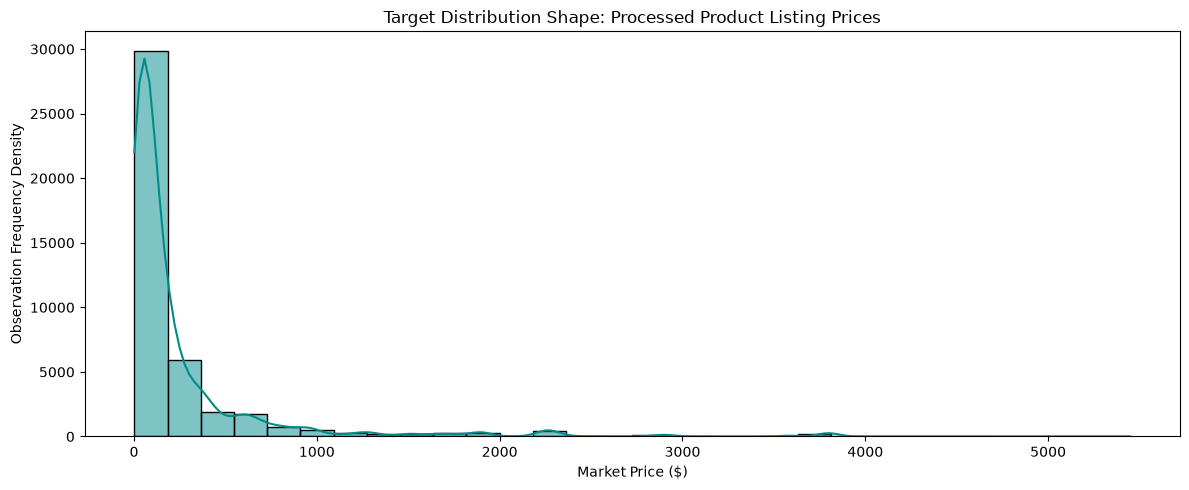

In [21]:
plt.figure(figsize=(12, 5))
sns.histplot(df['original_price'], bins=30, kde=True, color='darkcyan')
plt.title('Target Distribution Shape: Processed Product Listing Prices')
plt.xlabel('Market Price ($)')
plt.ylabel('Observation Frequency Density')
plt.tight_layout()
plt.show()

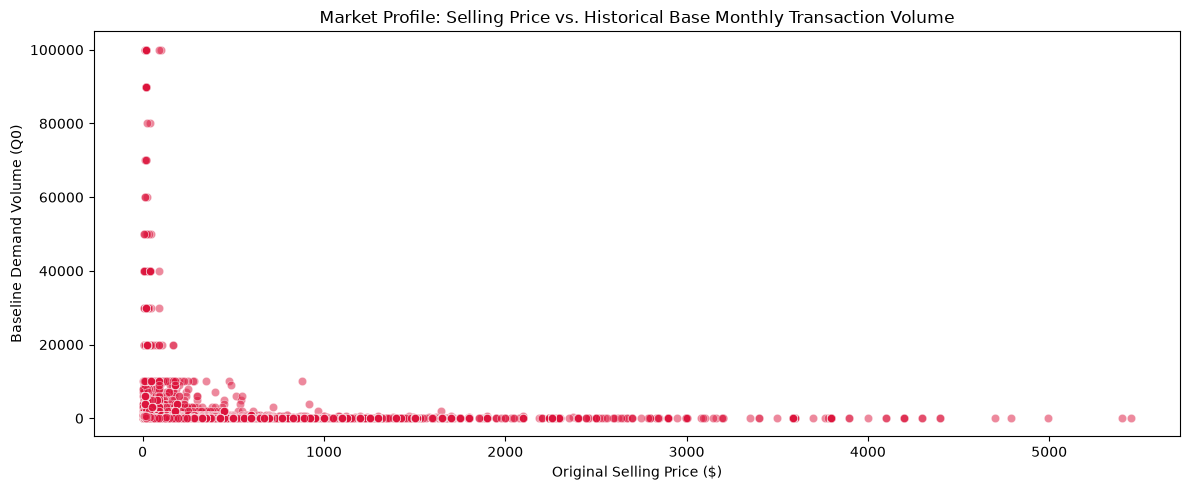

In [24]:
# Plot B: System Dynamics Scatter Correlation Matrix
plt.figure(figsize=(12, 5))
sns.scatterplot(x=df['original_price'], y=df['purchased_last_month'], alpha=0.5, color='crimson')
plt.title('Market Profile: Selling Price vs. Historical Base Monthly Transaction Volume')
plt.xlabel('Original Selling Price ($)')
plt.ylabel('Baseline Demand Volume (Q0)')
plt.tight_layout()
plt.show()

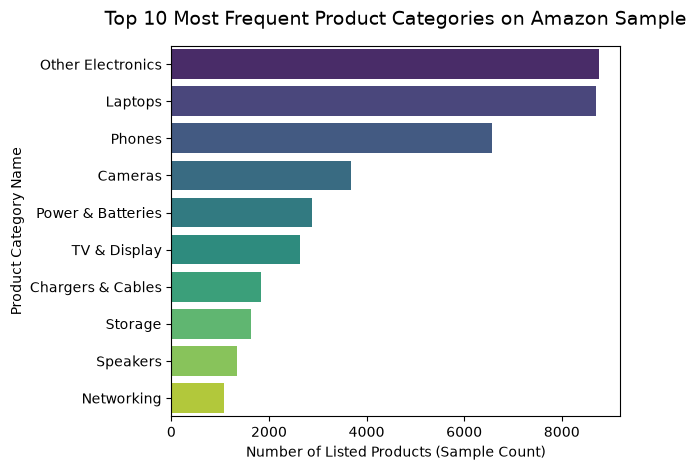

In [25]:
# Calculate value counts for top 10 highest-frequency categories
top_categories = df['product_category'].value_counts().head(10)

# Render Horizontal Bar Chart for better label legibility
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)

plt.title('Top 10 Most Frequent Product Categories on Amazon Sample', fontsize=14, pad=15)
plt.xlabel('Number of Listed Products (Sample Count)')
plt.ylabel('Product Category Name')
plt.tight_layout()
plt.show()

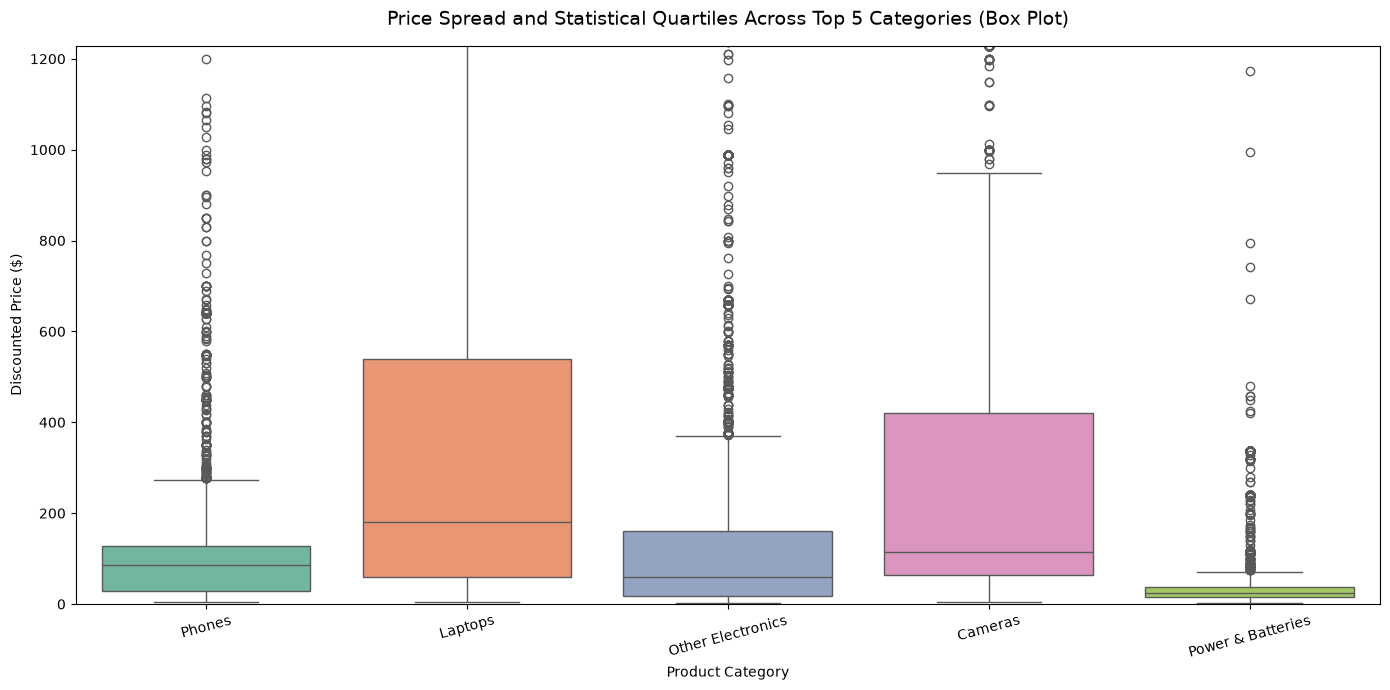

In [26]:
# Cell 16: Cross-Category Pricing Box Plot
plt.figure(figsize=(14, 7))

# Filter down to the top 5 largest categories to avoid visual clutter
top_5_cats = df['product_category'].value_counts().head(5).index
filtered_df = df[df['product_category'].isin(top_5_cats)]

# Draw Box Plot on log scale or clipped range if luxury outliers stretch the scale too far
sns.boxplot(x='product_category', y='discounted_price', data=filtered_df, hue='product_category', palette='Set2', legend=False)

# Optional: Clip the y-axis dynamically to the 95th percentile so extreme outliers don't squash the boxes
plt.ylim(0, filtered_df['discounted_price'].quantile(0.95))

plt.title('Price Spread and Statistical Quartiles Across Top 5 Categories (Box Plot)', fontsize=14, pad=15)
plt.xlabel('Product Category')
plt.ylabel('Discounted Price ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

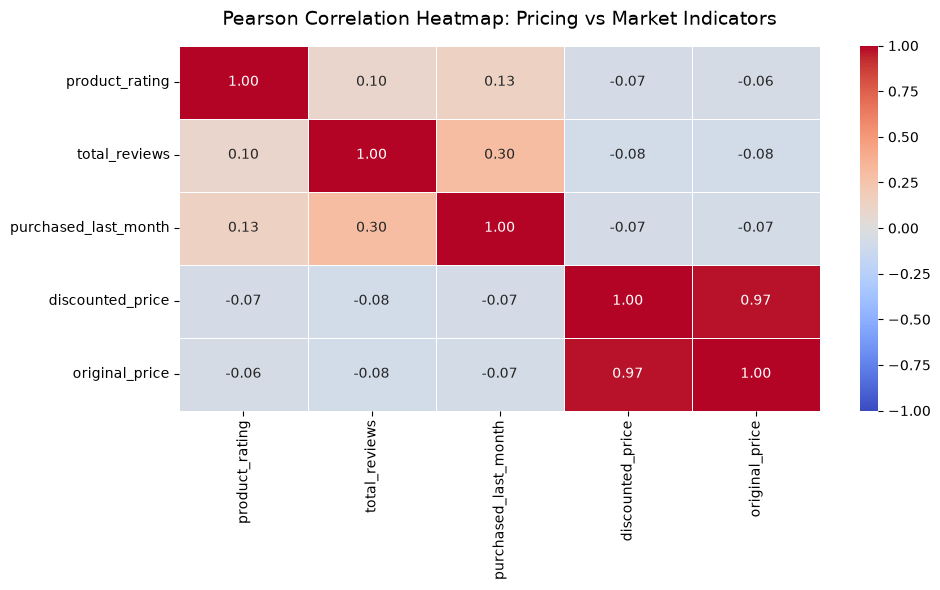

In [27]:
# Cell 12: Correlation Heatmap Construction
import seaborn as sns
import matplotlib.pyplot as plt

# Isolate clean continuous features
analytical_cols = ['product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price']
corr_matrix = df[analytical_cols].corr(numeric_only=True)

# Generate a styled Seaborn Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap: Pricing vs Market Indicators', fontsize=14, pad=15)
plt.tight_layout()
plt.show()